Appareil : cuda | Étude : Arkansas 2021
Feature dimension per timestep: 13  (bands=10, climate=3, static=0)
  [Arkansas_2021_Extended_with0.csv] Dropped 0/10000 rows with NaN (0.0%) — 10000 rows remaining.

  Class distribution after NaN removal:
    Soybeans    : 4704 samples
    Rice        : 2488 samples
    Corn        : 1392 samples
    Cotton      : 806 samples
    Others      : 610 samples

Echantillons : Train=1200, Val=300, Test=8500
Tenseur X shape : (1200, 36, 13)  →  (N, T=36, F=13)
Ordre des classes : ['Corn' 'Cotton' 'Others' 'Rice' 'Soybeans']
Epoch 10/200 | Val Acc: 95.33%
Epoch 20/200 | Val Acc: 98.67%
Epoch 30/200 | Val Acc: 95.67%
Epoch 40/200 | Val Acc: 98.33%
Epoch 50/200 | Val Acc: 98.00%
Epoch 60/200 | Val Acc: 97.67%
Epoch 70/200 | Val Acc: 97.67%
Epoch 80/200 | Val Acc: 97.00%
Early stopping at epoch 88
Meilleure précision validation : 0.9933


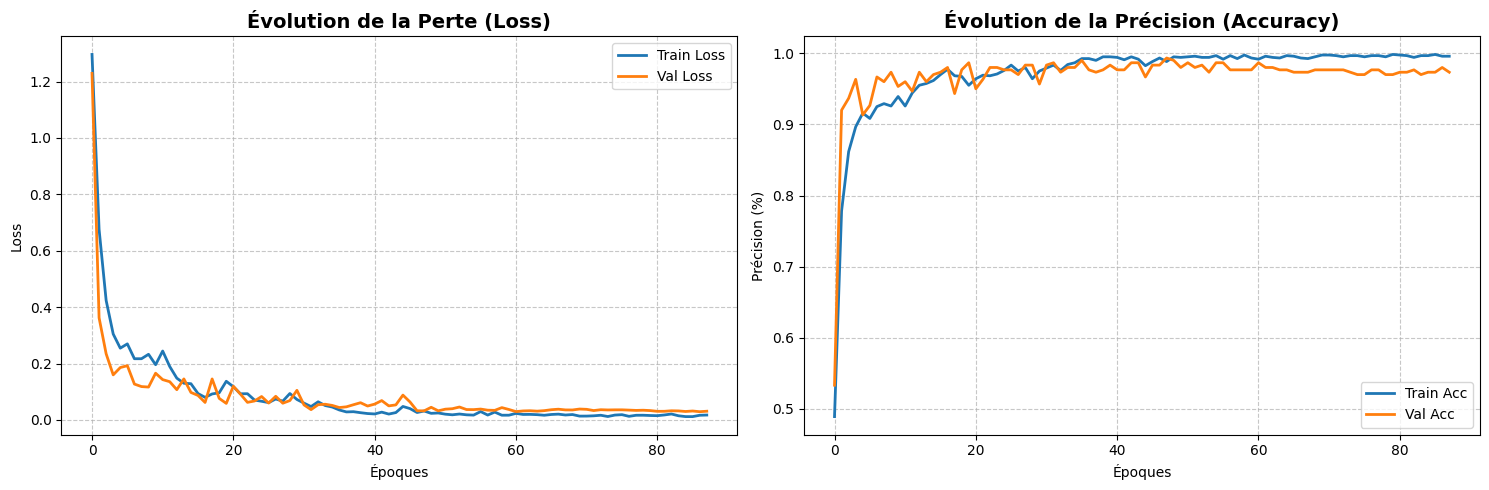


Overall Accuracy (OA) : 0.9859
Cohen's Kappa         : 0.9783
F1-Score (Macro)      : 0.9632


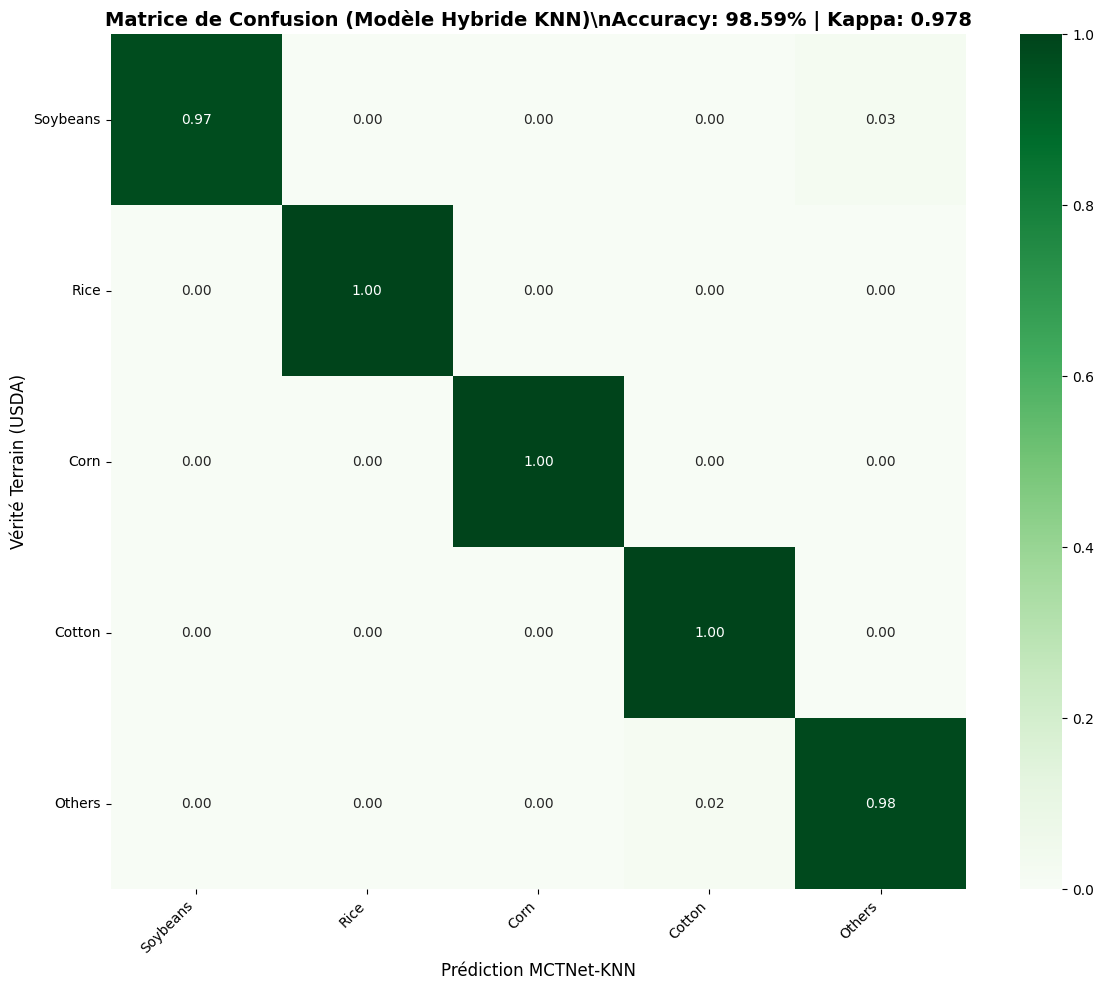


Détails par classe :
              precision    recall  f1-score   support

    Soybeans       1.00      0.97      0.99      4404
        Rice       1.00      1.00      1.00      2188
        Corn       1.00      1.00      1.00      1092
      Cotton       0.99      1.00      0.99       506
      Others       0.73      0.98      0.84       310

    accuracy                           0.99      8500
   macro avg       0.94      0.99      0.96      8500
weighted avg       0.99      0.99      0.99      8500



In [2]:
import os
import pandas as pd
import numpy as np
import copy
import torch
import math
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PATH = '/kaggle/input/datasets/drissiassil/dataset-extended/'
FILES = ['Arkansas_2021_Extended_with0.csv']
#dataset

N_DATES = 36
BATCH_SIZE = 64
K_NEIGHBORS = 8


TARGET_BANDS = ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'RE4', 'SWIR1', 'SWIR2']

time_varying_bases = ['mean_temp_t', 'total_precip_t', 'mean_dewpoint_t']

static_covars = [] #['soil_ph', 'soil_organic_carbon', 'soil_texture_class', 'elevation', 'landform_class']

dynamic_covars = [f"{base}{i:02d}" for base in time_varying_bases for i in range(1, N_DATES + 1)]
SELECTED_COVARS = static_covars + dynamic_covars

N_BANDS     = len(TARGET_BANDS)
N_CLIMATE   = len(time_varying_bases)
N_STATIC    = len(static_covars)
FEATURE_DIM = N_BANDS + N_CLIMATE + N_STATIC

print(f"Appareil : {DEVICE} | Étude : Arkansas 2021")
print(f"Feature dimension per timestep: {FEATURE_DIM}  "
      f"(bands={N_BANDS}, climate={N_CLIMATE}, static={N_STATIC})")


# ─────────────────────────────────────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────────────────────────────────────

class CropDataset(Dataset):
    def __init__(self, x, y, m):
        self.x = torch.FloatTensor(x)
        self.y = torch.LongTensor(y)
        self.m = torch.FloatTensor(m)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx): return self.x[idx], self.y[idx], self.m[idx]


def load_and_split_dataset(files, static_covars, time_varying_bases, n_dates):
    MY_LABELS = {
        0: 'Soybeans', 1: 'Rice', 2: 'Corn', 3: 'Cotton', 4: 'Others'
    }

    dynamic_cols = [f"{b}{i:02d}" for b in time_varying_bases for i in range(1, n_dates + 1)]
    all_required = static_covars + dynamic_cols

    X_list, y_list, M_list = [], [], []

    for f in files:
        full_path = os.path.join(PATH, f)
        if not os.path.exists(full_path):
            print(f"Fichier introuvable : {full_path}")
            continue

        df = pd.read_csv(full_path)

        n_before   = len(df)
        valid_mask = df[all_required].notna().all(axis=1)
        df         = df[valid_mask].reset_index(drop=True)
        n_dropped  = n_before - len(df)
        print(f"  [{f}] Dropped {n_dropped}/{n_before} rows with NaN "
              f"({n_dropped/n_before:.1%}) — {len(df)} rows remaining.")

        # ── 1. Spectral bands ──────────────────────────────────────────────
        if TARGET_BANDS:
            bands_list = []
            for b in TARGET_BANDS:
                cols = [f"{b}_t{t:02d}" for t in range(1, n_dates + 1)]
                bands_list.append(df[cols].values)
            X_bands = np.stack(bands_list, axis=2)
            feature_blocks = [X_bands]
        else:
            feature_blocks = []

        # ── 2. Climate covariates ──────────────────────────────────────────
        if time_varying_bases:
            climate_list = []
            for base in time_varying_bases:
                cols = [f"{base}{t:02d}" for t in range(1, n_dates + 1)]
                climate_list.append(df[cols].values)
            X_climate = np.stack(climate_list, axis=2)
            feature_blocks.append(X_climate)

        # ── 3. Static covariates ───────────────────────────────────────────
        if static_covars:
            static_vals = df[static_covars].values.astype(np.float32)
            X_static    = np.tile(static_vals[:, np.newaxis, :], (1, n_dates, 1))
            feature_blocks.append(X_static)

        # ── 4. Concatenate ─────────────────────────────────────────────────
        X_3d    = np.concatenate(feature_blocks, axis=2)
        y_names = df['label'].apply(lambda x: MY_LABELS.get(x, 'Others')).values
        M_2d    = df[[f"valid_t{t:02d}" for t in range(1, n_dates + 1)]].values

        X_list.append(X_3d)
        y_list.append(y_names)
        M_list.append(M_2d)

    X_all     = np.vstack(X_list)
    y_all_raw = np.concatenate(y_list)
    M_all     = np.vstack(M_list)

    le = LabelEncoder()
    le.fit(list(MY_LABELS.values()))
    y_all = le.transform(y_all_raw)

    print("\n  Class distribution after NaN removal:")
    for c, name in MY_LABELS.items():
        encoded = le.transform([name])[0]
        count   = (y_all == encoded).sum()
        print(f"    {name:12s}: {count} samples")

    train_idx, val_idx, test_idx = [], [], []
    np.random.seed(69)
    for c in np.unique(y_all):
        indices = np.where(y_all == c)[0]
        np.random.shuffle(indices)
        n_train = min(len(indices), 240)
        n_val   = min(len(indices) - n_train, 60)
        train_idx.extend(indices[:n_train])
        val_idx.extend(indices[n_train:n_train + n_val])
        test_idx.extend(indices[n_train + n_val:])

    N_tr, T, F = X_all[train_idx].shape
    scaler = StandardScaler()
    scaler.fit(X_all[train_idx].reshape(-1, F))

    def scale(idx_list):
        arr = X_all[idx_list]
        n   = arr.shape[0]
        return scaler.transform(arr.reshape(-1, F)).reshape(n, T, F)

    return (scale(train_idx), y_all[train_idx], M_all[train_idx],
            scale(val_idx),   y_all[val_idx],   M_all[val_idx],
            scale(test_idx),  y_all[test_idx],  M_all[test_idx],
            le)


X_train, y_train, M_train, \
X_val,   y_val,   M_val,   \
X_test,  y_test,  M_test,  \
encoder = load_and_split_dataset(FILES, static_covars, time_varying_bases, N_DATES)

train_loader = DataLoader(CropDataset(X_train, y_train, M_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CropDataset(X_val,   y_val,   M_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(CropDataset(X_test,  y_test,  M_test),  batch_size=BATCH_SIZE)

print(f"\nEchantillons : Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
print(f"Tenseur X shape : {X_train.shape}  →  (N, T={N_DATES}, F={FEATURE_DIM})")
print(f"Ordre des classes : {encoder.classes_}")


# ─────────────────────────────────────────────────────────────────────────────
# ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────

class BatchKNN(nn.Module):
    def __init__(self, k=5):
        super().__init__()
        self.k = k

    def forward(self, x):
        B, D = x.size()
        if B < self.k:
            return x
        dist = torch.cdist(x, x)
        _, topk_idx = torch.topk(dist, self.k, largest=False)
        neighbors = x[topk_idx]
        return neighbors.mean(dim=1)


class ECA(nn.Module):
    def __init__(self, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.transpose(-1, -2)).transpose(-1, -2)
        return x * self.sigmoid(y)


class ALPE(nn.Module):
    def __init__(self, d_model, max_len=36):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))
        self.eca         = ECA()
        self.conv_refine = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, groups=d_model)

    def forward(self, x, mask):
        b, t, c = x.size()
        pe  = self.pe.expand(b, -1, -1)
        pe  = pe * mask.unsqueeze(-1)
        pe_f = self.conv_refine(pe.transpose(1, 2))
        pe_f = self.eca(pe_f).transpose(1, 2)
        return pe_f


class CNNSubModule(nn.Module):
    def __init__(self, in_dim, out_dim, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1    = nn.Conv1d(in_dim,  out_dim, kernel_size, padding=pad)
        self.bn1      = nn.BatchNorm1d(out_dim)
        self.conv2    = nn.Conv1d(out_dim, out_dim, kernel_size, padding=pad)
        self.bn2      = nn.BatchNorm1d(out_dim)
        self.shortcut = nn.Conv1d(in_dim, out_dim, kernel_size=1)
        self.relu     = nn.ReLU()

    def forward(self, x):
        h        = x.transpose(1, 2)
        residual = self.shortcut(h)
        h        = self.relu(self.bn1(self.conv1(h)))
        h        = self.bn2(self.conv2(h))
        return self.relu(h + residual)


class TransformerSubModule(nn.Module):
    def __init__(self, d_model, n_head, dropout=0.3):
        super().__init__()
        self.mha   = nn.MultiheadAttention(d_model, n_head, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, pe=None):
        x_pe        = x + pe if pe is not None else x
        attn_out, _ = self.mha(x_pe, x_pe, x_pe)
        x2          = self.norm1(attn_out + x_pe)
        ffn_out     = self.ffn(x2)
        return self.norm2(ffn_out + x2)


class CTFusionBlock(nn.Module):
    def __init__(self, in_dim, out_dim, n_head=5, dropout=0.3):
        super().__init__()
        self.transformer = TransformerSubModule(in_dim, n_head, dropout)
        self.cnn         = CNNSubModule(in_dim, out_dim)
        self.fusion_conv = nn.Conv1d(out_dim + in_dim, out_dim, kernel_size=1)
        self.pool        = nn.MaxPool1d(2)

    def forward(self, x, pe=None):
        t_out = self.transformer(x, pe)
        c_out = self.cnn(x)
        fused = torch.cat([c_out, t_out.transpose(1, 2)], dim=1)
        fused = self.fusion_conv(fused)
        return self.pool(fused).transpose(1, 2)


class MCTNet_KNN(nn.Module):
    def __init__(self, n_classes, feature_dim=FEATURE_DIM, d_model=30, k_neighbors=5):
        super().__init__()
        self.input_proj = nn.Linear(feature_dim, d_model)
        self.alpe       = ALPE(d_model=d_model, max_len=36)
        self.stage1     = CTFusionBlock(d_model, 20, n_head=5)
        self.stage2     = CTFusionBlock(20,      40, n_head=5)
        self.stage3     = CTFusionBlock(40,      80, n_head=5)
        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.knn_layer  = BatchKNN(k=k_neighbors)
        self.classifier = nn.Linear(80, n_classes)

    def forward(self, x, mask):
        x    = self.input_proj(x)
        pe   = self.alpe(x, mask)
        x    = self.stage1(x, pe=pe)
        x    = self.stage2(x)
        x    = self.stage3(x)
        x    = self.global_pool(x.transpose(1, 2)).squeeze(-1)
        x    = self.knn_layer(x)
        return self.classifier(x)


# ─────────────────────────────────────────────────────────────────────────────
# ENTRAÎNEMENT 
# ─────────────────────────────────────────────────────────────────────────────

n_classes = len(encoder.classes_)
model     = MCTNet_KNN(n_classes, feature_dim=FEATURE_DIM, d_model=30, k_neighbors=K_NEIGHBORS).to(DEVICE)

EPOCHS                  = 200
EARLY_STOPPING_PATIENCE = 40

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10
)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc      = 0.0
best_model_wts    = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss, train_correct = 0.0, 0
    for b_x, b_y, b_m in train_loader:
        b_x, b_y, b_m = b_x.to(DEVICE), b_y.to(DEVICE), b_m.to(DEVICE)
        optimizer.zero_grad()
        out  = model(b_x, b_m)
        loss = criterion(out, b_y)
        loss.backward()
        optimizer.step()
        running_loss  += loss.item()
        train_correct += (out.argmax(1) == b_y).sum().item()

    model.eval()
    v_loss, v_corr = 0.0, 0
    with torch.no_grad():
        for vx, vy, vm in val_loader:
            vx, vy, vm = vx.to(DEVICE), vy.to(DEVICE), vm.to(DEVICE)
            out     = model(vx, vm)
            v_loss += criterion(out, vy).item()
            v_corr += (out.argmax(1) == vy).sum().item()

    epoch_train_acc = train_correct / len(X_train)
    epoch_val_acc   = v_corr       / len(X_val)

    history['train_loss'].append(running_loss / len(train_loader))
    history['val_loss'].append(v_loss         / len(val_loader))
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    scheduler.step(epoch_val_acc)
    if epoch_val_acc > best_val_acc:
        best_val_acc      = epoch_val_acc
        best_model_wts    = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {epoch_val_acc:.2%}")

model.load_state_dict(best_model_wts)
print(f"Meilleure précision validation : {best_val_acc:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION & ÉVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def plot_history(history):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
    plt.plot(history['val_loss'],   label='Val Loss',   color='#ff7f0e', lw=2)
    plt.title('Évolution de la Perte (Loss)', fontsize=14, fontweight='bold')
    plt.xlabel('Époques'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc', color='#1f77b4', lw=2)
    plt.plot(history['val_acc'],   label='Val Acc',   color='#ff7f0e', lw=2)
    plt.title('Évolution de la Précision (Accuracy)', fontsize=14, fontweight='bold')
    plt.xlabel('Époques'); plt.ylabel('Précision (%)')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_history(history)

def evaluate_mctnet_knn(model, test_loader, device, encoder):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for b_x, b_y, b_m in test_loader:
            outputs = model(b_x.to(device), b_m.to(device))
            all_y.extend(b_y.numpy())
            all_p.extend(outputs.argmax(1).cpu().numpy())
    all_y, all_p = np.array(all_y), np.array(all_p)

    kappa = cohen_kappa_score(all_y, all_p)
    oa    = accuracy_score(all_y, all_p)
    f1    = f1_score(all_y, all_p, average='macro')
    print(f"\nOverall Accuracy (OA) : {oa:.4f}")
    print(f"Cohen's Kappa         : {kappa:.4f}")
    print(f"F1-Score (Macro)      : {f1:.4f}")

    DISPLAY_ORDER = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']
    label_order   = [list(encoder.classes_).index(name) for name in DISPLAY_ORDER]
    cm = confusion_matrix(all_y, all_p, labels=label_order, normalize='true')

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=DISPLAY_ORDER, yticklabels=DISPLAY_ORDER)
    plt.title(f'Matrice de Confusion (Modèle Hybride KNN)\\nAccuracy: {oa:.2%} | Kappa: {kappa:.3f}',
              fontsize=14, fontweight='bold')
    plt.ylabel('Vérité Terrain (USDA)', fontsize=12)
    plt.xlabel('Prédiction MCTNet-KNN', fontsize=12)
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print("Détails par classe :")
    print(classification_report(all_y, all_p,
                                labels=label_order,
                                target_names=DISPLAY_ORDER))
    print("="*60)

evaluate_mctnet_knn(model, test_loader, DEVICE, encoder)

